In [1]:
# executar  uv pip install transformers diffusers

In [1]:
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM
import torch

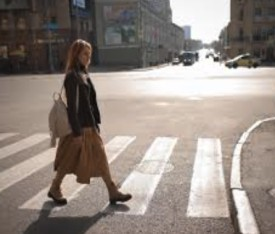

In [ ]:
from PIL import Image
image = Image.open('mulher_faixa_pedestre.jpg')
image

In [3]:
from transformers import pipeline
pipe = pipeline("zero-shot-image-classification", model="openai/clip-vit-base-patch32")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [4]:
import time
labels = ["gato", "cachorro", "homem", "mulher",  "carro", "mochila"]
inicio = time.time()
resposta = pipe(image, candidate_labels=labels)
fim = time.time()

print(resposta)
print('duracao:', fim-inicio)

[{'score': 0.5318208932876587, 'label': 'mulher'}, {'score': 0.17172259092330933, 'label': 'homem'}, {'score': 0.1666686087846756, 'label': 'carro'}, {'score': 0.1148584634065628, 'label': 'mochila'}, {'score': 0.011282024905085564, 'label': 'cachorro'}, {'score': 0.0036473791114985943, 'label': 'gato'}]
duracao: 0.3788168430328369


In [5]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

# Inicializa o pipeline com um modelo especializado em humanos
segmenter = pipeline("image-segmentation", model="fashn-ai/fashn-human-parser")

import torch

# Load model and processor
processor = SegformerImageProcessor.from_pretrained("fashn-ai/fashn-human-parser")
model = SegformerForSemanticSegmentation.from_pretrained("fashn-ai/fashn-human-parser")


Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

The image processor of type `SegformerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

In [ ]:
inputs = processor(images=image, return_tensors="pt")

# O resultado é uma lista de dicionários contendo 'label', 'score' e 'mask' (PIL Image)
# for item in result:
#     print(f"Detectado: {item['label']} com score {item['score']:.2f}")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits  # (1, 18, H/4, W/4)

# Upsample to original size and get predictions
upsampled = torch.nn.functional.interpolate(
    logits, size=image.size[::-1], mode="bilinear", align_corners=False
)
predictions = upsampled.argmax(dim=1).squeeze().numpy()



CausalLMOutputWithPast(loss=None, logits=tensor([[[ 8.0000,  6.4688,  3.9531,  ..., -4.3438, -4.3438, -4.3438],
         [ 5.0938,  5.1562,  1.8906,  ..., -5.4375, -5.4375, -5.4375],
         [ 2.7344,  4.8750, -0.5547,  ..., -5.5000, -5.5000, -5.5000],
         ...,
         [ 4.1875,  5.6562, -0.9648,  ..., -5.5625, -5.5625, -5.5625],
         [ 4.7500,  3.6562, -0.0231,  ..., -5.8125, -5.8125, -5.8125],
         [ 3.5156,  4.9688, -1.4688,  ..., -6.9688, -6.9688, -6.9688]]],
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=None, attentions=None)


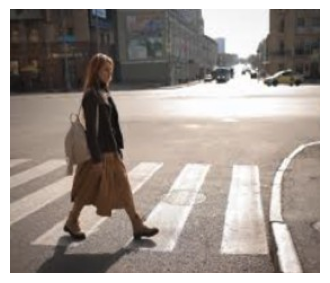

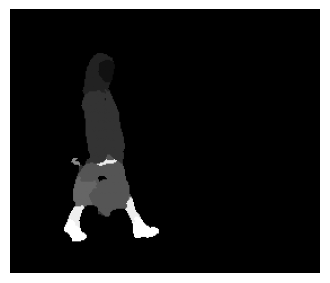

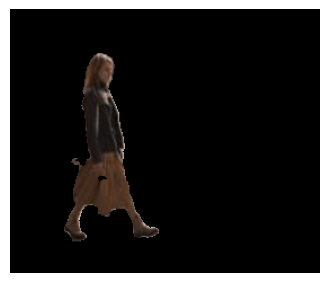

In [7]:
import numpy as np
import matplotlib.pyplot as plt
img_np = np.array(image)
fig = plt.figure(figsize=(4, 4))
plt.axis('off')
plt.imshow(img_np, cmap='gray')

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits  # (1, 18, H/4, W/4)

upsampled = torch.nn.functional.interpolate(
    logits, size=image.size[::-1], mode="bilinear", align_corners=False
)
predictions = upsampled.argmax(dim=1).squeeze().numpy()


fig = plt.figure(figsize=(4, 4))
plt.axis('off')
plt.imshow(predictions, cmap='gray')

fig = plt.figure(figsize=(4, 4))
plt.axis('off')
imagem_segmentada = img_np.copy()
filtro = (predictions==0)
imagem_segmentada[filtro] = 0
plt.imshow(imagem_segmentada)


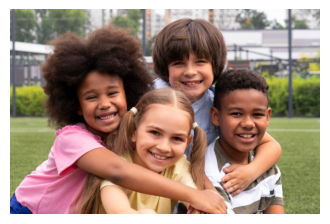

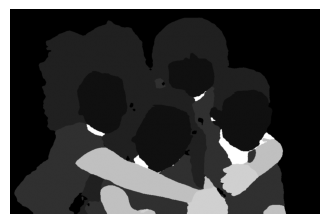

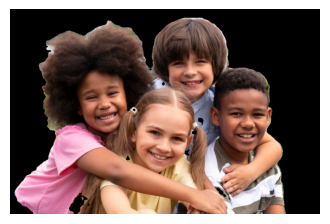

In [8]:
image = Image.open('foto_site_free_pick.png')
image = image.convert('RGB')

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits  # (1, 18, H/4, W/4)

# Upsample to original size and get predictions
upsampled = torch.nn.functional.interpolate(
    logits, size=image.size[::-1], mode="bilinear", align_corners=False
)
predictions = upsampled.argmax(dim=1).squeeze().numpy()


img_np = np.array(image)
fig = plt.figure(figsize=(4, 4))
plt.axis('off')
plot = plt.imshow(img_np, cmap='gray')

fig = plt.figure(figsize=(4, 4))
plt.axis('off')
plot = plt.imshow(predictions, cmap='gray')

fig = plt.figure(figsize=(4, 4))
plt.axis('off')
imagem_segmentada = img_np.copy()
filtro = (predictions==0)
imagem_segmentada[filtro] = 0
plot = plt.imshow(imagem_segmentada)
